# Qubit and Quantum States ⚛️

A **qubit (quantum bit)** is the basic unit of quantum information.

Unlike a classical bit, which can only be `0` or `1`, a qubit can exist in:

- The `|0⟩` state
- The `|1⟩` state
- A **superposition** of both states

A general single-qubit state can be written as:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
$$

where:

$$
|\alpha|^2 + |\beta|^2 = 1
$$

The values $|\alpha|^2$ and $|\beta|^2$ represent the probabilities of measuring `0` and `1`.

In this notebook, we will:

1. Create a qubit in the `|0⟩` state.
2. Inspect its statevector.
3. Apply the X gate to obtain the `|1⟩` state.
4. Create a superposition using the Hadamard gate.
5. Calculate theoretical probabilities.
6. Measure the qubit using a simulator.
7. Visualize the measurement results.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## 1. Creating a Qubit

A quantum circuit containing one qubit can be created using:

```python
QuantumCircuit(1)

In [4]:
qc = QuantumCircuit(1)

print("Quantum Circuit:")
print(qc.draw())

Quantum Circuit:
   
q: 
   


## 2. Inspecting the Initial Quantum State

We can use Qiskit's `Statevector` class to inspect the mathematical state of our qubit.

The state $|0\rangle$ is represented as:

$$
|0\rangle =
\begin{bmatrix}
1\\
0
\end{bmatrix}
$$

Therefore, the qubit has:

- 100% probability of being measured as `0`
- 0% probability of being measured as `1`

In [5]:
# Obtain the statevector of the qubit
state = Statevector.from_instruction(qc)

print("Initial Quantum State:")
print(state)

print("\nInitial Probabilities:")
print(state.probabilities_dict())

Initial Quantum State:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Initial Probabilities:
{np.str_('0'): np.float64(1.0)}


### Understanding the Statevector

The statevector should look similar to:

```text
Statevector([1.+0.j, 0.+0.j])

## 3. Applying the X Gate

The **X gate** is similar to a NOT operation for a classical bit.

It transforms:

$$
|0\rangle \rightarrow |1\rangle
$$

and:

$$
|1\rangle \rightarrow |0\rangle
$$

Its matrix representation is:

$$
X =
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix}
$$

In [6]:
# Apply the X gate to the qubit
qc.x(0)

print("Circuit After X Gate:")
print(qc.draw())

# Obtain the new statevector
state_after_x = Statevector.from_instruction(qc)

print("\nState After X Gate:")
print(state_after_x)

print("\nProbabilities After X Gate:")
print(state_after_x.probabilities_dict())

Circuit After X Gate:
   ┌───┐
q: ┤ X ├
   └───┘

State After X Gate:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

Probabilities After X Gate:
{np.str_('1'): np.float64(1.0)}


### Result

After applying the X gate, the state changes from:

$$
|0\rangle
$$

to:

$$
|1\rangle
$$

The `|1⟩` state is represented as:

$$
|1\rangle =
\begin{bmatrix}
0\\
1
\end{bmatrix}
$$

Therefore:

$$
P(0)=0
$$

$$
P(1)=1
$$

The qubit is now guaranteed to produce `1` when measured.

## 4. Creating a Superposition

One of the most important concepts in quantum computing is **superposition**.

The **Hadamard (H) gate** can transform the `|0⟩` state into an equal superposition:

$$
H|0\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

This means the quantum state contains amplitudes for both `|0⟩` and `|1⟩`.

The probability of each measurement outcome is:

$$
P(0)=\left|\frac{1}{\sqrt{2}}\right|^2=\frac{1}{2}
$$

$$
P(1)=\left|\frac{1}{\sqrt{2}}\right|^2=\frac{1}{2}
$$

Therefore:

$$
P(0)=50\%
$$

$$
P(1)=50\%
$$

In [7]:
# Create a fresh one-qubit circuit
superposition_qc = QuantumCircuit(1)

# Apply the Hadamard gate
superposition_qc.h(0)

print("Superposition Circuit:")
print(superposition_qc.draw())

Superposition Circuit:
   ┌───┐
q: ┤ H ├
   └───┘


In [8]:
# Obtain the superposition state
superposition_state = Statevector.from_instruction(
    superposition_qc
)

print("Superposition State:")
print(superposition_state)

print("\nSuperposition Probabilities:")
print(superposition_state.probabilities_dict())

Superposition State:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Superposition Probabilities:
{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


### Understanding the Superposition State

The statevector should be approximately:

```text
[0.70710678, 0.70710678]

## 5. Measuring the Superposition

The statevector gives us the **theoretical probabilities**.

To observe actual measurement outcomes, we need to measure the qubit.

We will run the circuit multiple times, called **shots**.

For this experiment, we will use:

$$
1024\text{ shots}
$$

Since the theoretical probabilities are 50% and 50%, we expect the results to be approximately evenly divided between `0` and `1`.

The results will not necessarily be exactly `512` and `512` because quantum measurement is probabilistic.

In [9]:
# Create a circuit with one qubit and one classical bit
measurement_qc = QuantumCircuit(1, 1)

# Create superposition
measurement_qc.h(0)

# Measure the qubit
measurement_qc.measure(0, 0)

print("Measurement Circuit:")
print(measurement_qc.draw())

Measurement Circuit:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


In [10]:
# Create the simulator
simulator = AerSimulator()

# Run the circuit 1024 times
job = simulator.run(
    measurement_qc,
    shots=1024
)

# Get the results
result = job.result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

print("\nTotal Shots:")
print(sum(counts.values()))

Measurement Results:
{'1': 526, '0': 498}

Total Shots:
1024


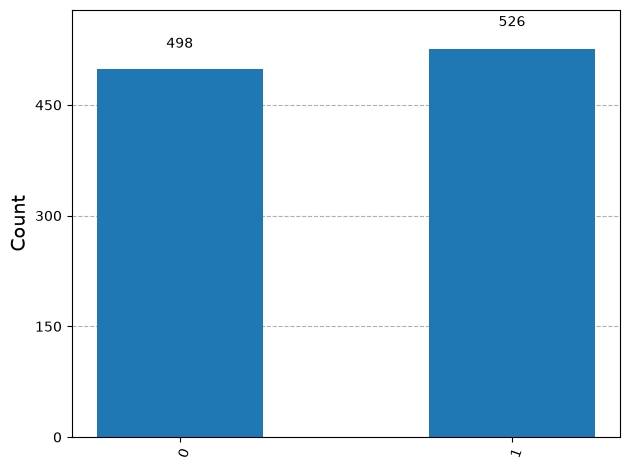

In [12]:
# Visualize the measurement results

fig = plot_histogram(counts)

display(fig)

## 6. Analyzing the Results

The histogram should show two outcomes:

- `0`
- `1`

Both should appear approximately 50% of the time.

For example, one simulation could produce:

```text
0 → 507
1 → 517


# Key Takeaways ⚛️

- A **qubit** is the basic unit of quantum information.
- A newly initialized qubit starts in the `|0⟩` state.
- The **X gate** transforms `|0⟩` into `|1⟩`.
- The **Hadamard gate** can create an equal superposition.
- A quantum state can be represented using a **statevector**.
- The squared magnitude of an amplitude gives its measurement probability.
- Measurement converts the quantum state into a classical result.
- Multiple shots allow us to observe the probability distribution experimentally.
- Experimental results may differ slightly from theoretical probabilities because of statistical variation.

### Core Quantum Computing Workflow

$$
\boxed{
\text{Initialize}
\rightarrow
\text{Apply Gates}
\rightarrow
\text{Quantum State}
\rightarrow
\text{Measure}
\rightarrow
\text{Analyze Results}
}
$$